# **AML LAB**

## **Experiment 8**

##Implement Multiclass Classification models for students Performance Level analysis and perform comparative analysis. (Random Forest, Decision Tree, Multinomial Logistic Regression, XGBoost, K-Nearest Neighbors).


###1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

###2. Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Applied_ML_Lab/Lab_6/Exp8_multiclass_classification_dataset_500_samples.csv")
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,Medium,Yes,B,1
1,19.31,94.09,81.10,56.73,Low,Yes,B,1
2,23.24,61.01,70.72,52.73,Medium,Yes,A,0
3,27.62,80.63,62.24,64.95,Low,Yes,C,0
4,18.83,68.49,78.38,62.45,High,Yes,B,0


###3. Data Understanding

In [ ]:
df.info()
df.isnull().sum()

# Check class distribution
df['Performance_Level'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            500 non-null    float64
 1   Attendance_Percentage  500 non-null    float64
 2   Assignment_Score       500 non-null    float64
 3   Internal_Marks         500 non-null    float64
 4   Participation          500 non-null    object 
 5   Internet_Access        500 non-null    object 
 6   Previous_Grade         500 non-null    object 
 7   Performance_Level      500 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 31.4+ KB


,count
Performance_Level,
1,249
0,247
2,4


###4. Handle Missing Values

In [ ]:
df = df.dropna()

###5. Encode Categorical Variables

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,2,1,1,1
1,19.31,94.09,81.10,56.73,1,1,1,1
2,23.24,61.01,70.72,52.73,2,1,0,0
3,27.62,80.63,62.24,64.95,1,1,2,0
4,18.83,68.49,78.38,62.45,0,1,1,0


###6. Feature-Target Split

In [ ]:
X = df.drop("Performance_Level", axis=1)
y = df["Performance_Level"]

###7. Feature Scaling (Required for KNN & Logistic)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###8. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

###9. Initialize Models

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Multinomial Logistic Regression": LogisticRegression(max_iter=1000, multi_class='multinomial'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

###10. Train and Evaluate Models

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results[name] = [accuracy, precision, recall, f1]

    print("\nModel:", name)
    print("Accuracy:", accuracy)
    print("Precision (Macro):", precision)
    print("Recall (Macro):", recall)
    print("F1-Score (Macro):", f1)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model: Decision Tree
Accuracy: 0.87
Precision (Macro): 0.9116666666666666
Recall (Macro): 0.9115646258503401
F1-Score (Macro): 0.911555416710056

Confusion Matrix:
 [[43  6  0]
 [ 7 42  0]
 [ 0  0  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87        49
           1       0.88      0.86      0.87        49
           2       1.00      1.00      1.00         2

    accuracy                           0.87       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.87      0.87      0.87       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Model: Random Forest
Accuracy: 0.9
Precision (Macro): 0.5999733226623983
Recall (Macro): 0.6122448979591837
F1-Score (Macro): 0.6059863945578231

Confusion Matrix:
 [[46  3  0]
 [ 5 44  0]
 [ 0  2  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92        49
           1       0.90      0.90      0.90        49
           2       0.00      0.00      0.00         2

    accuracy                           0.90       100
   macro avg       0.60      0.61      0.61       100
weighted avg       0.88      0.90      0.89       100


Model: Multinomial Logistic Regression
Accuracy: 0.97
Precision (Macro): 0.6474358974358975
Recall (Macro): 0.6598639455782312
F1-Score (Macro): 0.6533292504508182

Confusion Matrix:
 [[48  1  0]
 [ 0 49  0]
 [ 0  2  0]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.94      1.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

###11. Comparative Performance Table

In [ ]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"]
)
results_df

,Decision Tree,Random Forest,Multinomial Logistic Regression,K-Nearest Neighbors,XGBoost
Accuracy,0.870000,0.900000,0.970000,0.790000,0.950000
Precision (Macro),0.911667,0.599973,0.647436,0.527244,0.634081
Recall (Macro),0.911565,0.612245,0.659864,0.537415,0.646259
F1-Score (Macro),0.911555,0.605986,0.653329,0.532068,0.639856


###12. Visualization

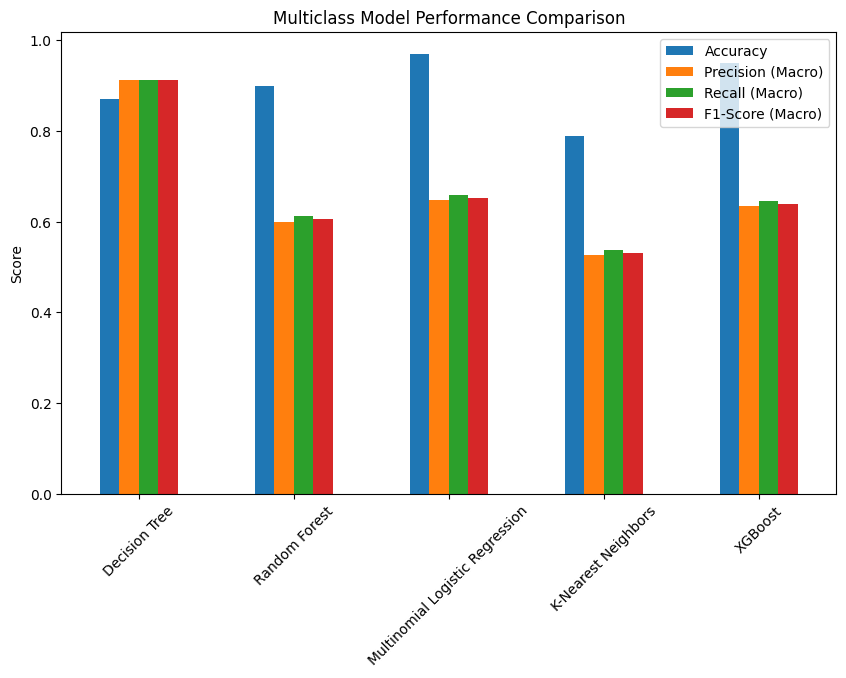

In [ ]:
results_df.T.plot(kind='bar', figsize=(10,6))
plt.title("Multiclass Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()